In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # 외부 폰트 쓰는 라이브러리
import seaborn as sns

# 그래프를 그리기위한 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic' # 폰트설정
# plt.rcParams['font.family'] = 'AppleGothic' # Mac 폰트설정
plt.rcParams['figure.figsize'] = 12,6 # 그래프의 크기
plt.rcParams['font.size'] = 14 # 글자 크기
plt.rcParams['axes.unicode_minus'] = False

### Rug Plot
- 1차원 데이터에 대한 분포를 표현한다.
- 데이터의 분포를 볼 때는 산점도를 주로 이용하는데 산점도는 2차원 데이터를 통해 시각화할 수 있다.
- 이에 1차원 데이터 분포를 확인하기 위한 Rug Plot을 제공하고 있다.

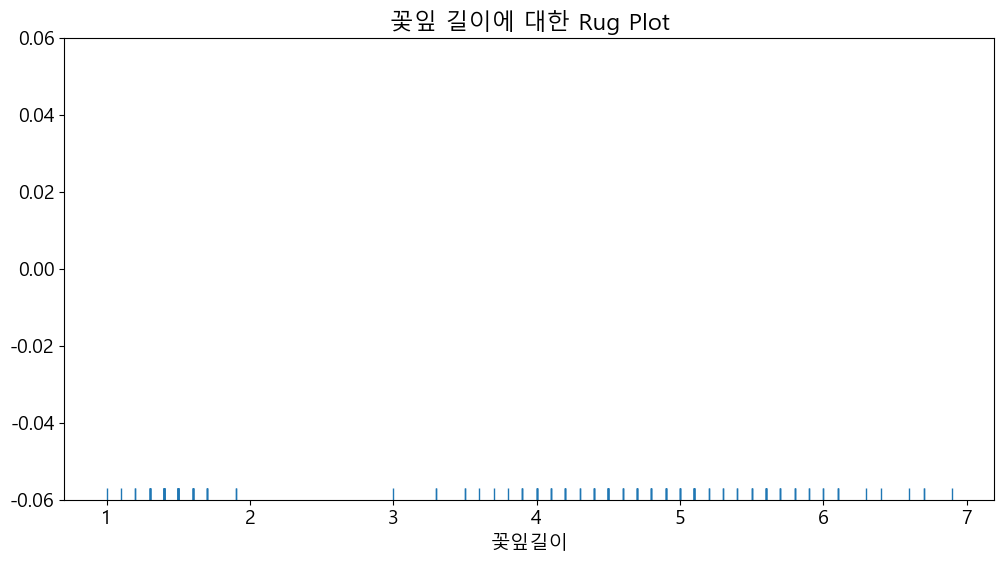

In [2]:
iris = pd.read_csv('data/iris.csv')
iris.columns= ['꽃받침길이','꽃받침너비','꽃잎길이','꽃잎너비','품종']
a1 = iris['꽃잎길이']

sns.rugplot(a1)
plt.title('꽃잎 길이에 대한 Rug Plot')
plt.show()

### KDE
- 히스토그램은 막대 그래프로 값 분포를 표현하지만 KDE는 선으로 표현한다.
- 막대는 양을 표현하고 kde는 밀도를 표현한다.

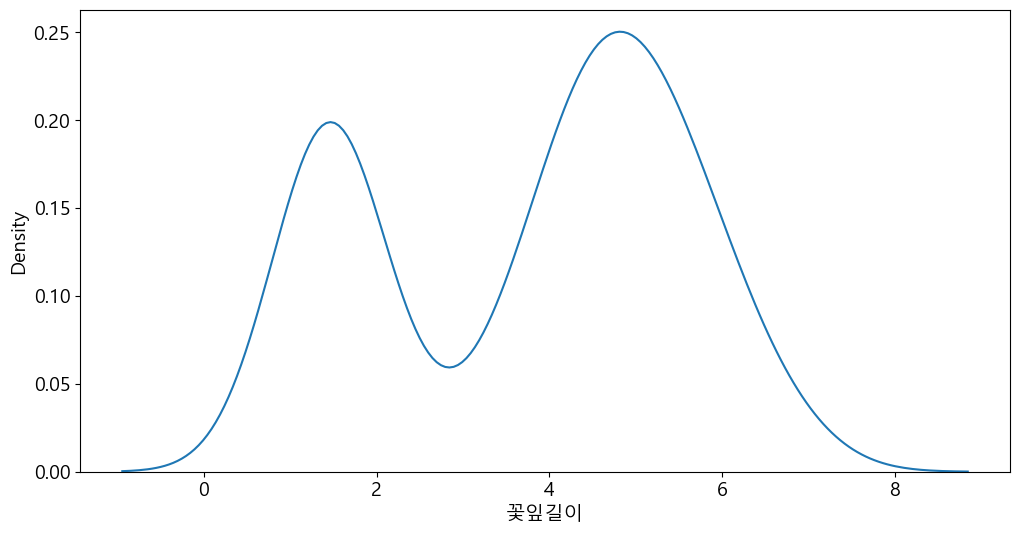

In [3]:
sns.kdeplot(iris['꽃잎길이'])
plt.show()

### displot
- 히스토그램, Rug, KDE를 같이 표현한 그래프이다.

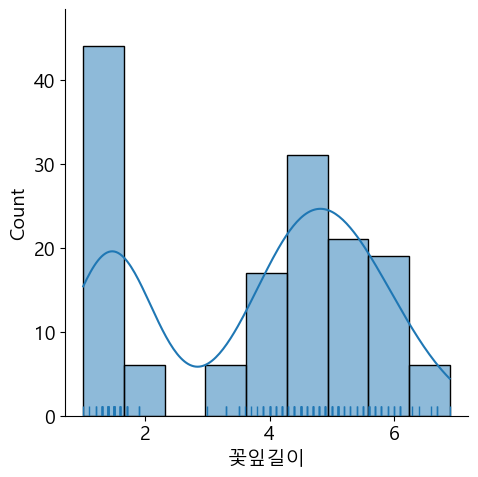

In [4]:
sns.displot(iris['꽃잎길이'], rug=True, kde=True)
plt.show()

### 막대그래프

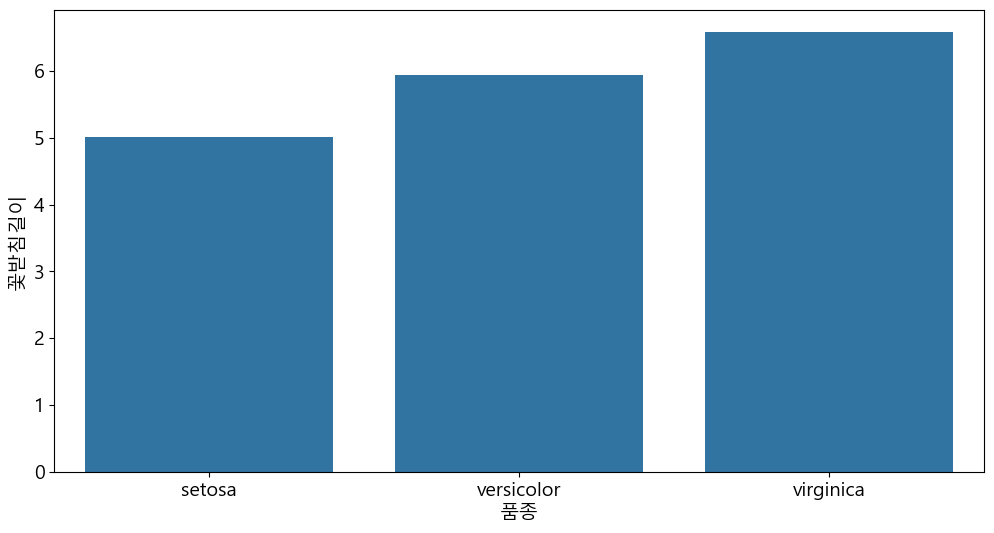

In [5]:
# data : 데이터 프레임
# x : x축에 반영할 컬럼 이름
# y : y축에 반영할 컬럼 이름
# estimator : 통계값을 구할 함수의 이름 문자열 (신뢰구간)
# erorbar : None이면 신뢰구간 표시x 바꾸고 싶다면 ('ci',90)
sns.barplot(data=iris, x='품종', y='꽃받침길이', estimator='mean', errorbar=None)
plt.show()

### 카운트 플롯
- 특정 컬럼의 도수분포를 구해 이를 기반으로 막대 그래프를 그려준다.
- 특정 컬럼의 데이터의 각 종류별로 몇 개씩 저장되어 있는지 확인할 수 있다.

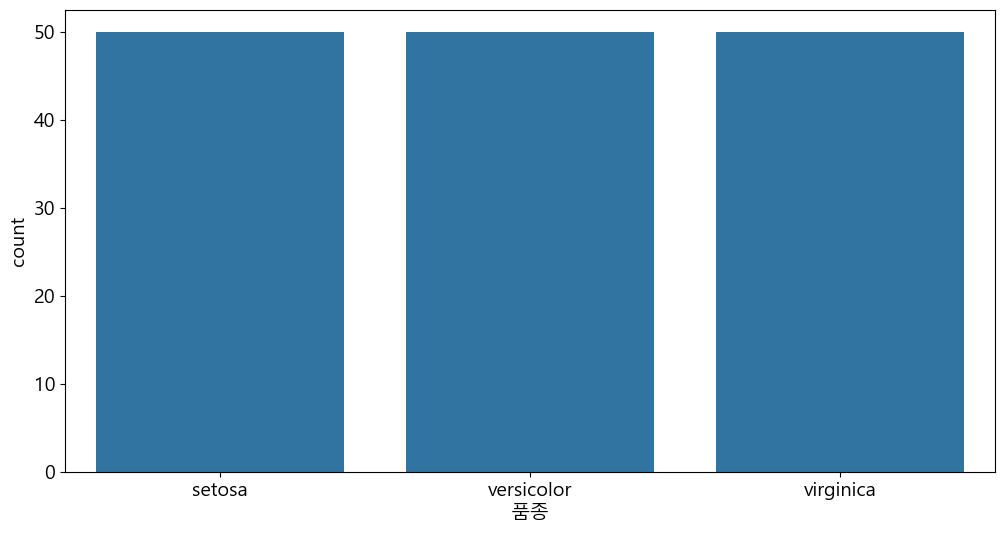

In [6]:
sns.countplot(data=iris, x='품종')
plt.show()

### jointplot
- 산점도와 히스토그램을 같이 보여준다.
- 중앙에는 x축과 y축을 이용한 산점도를 표현한다.
- 상단에는 x축의 데이터를 이용한 히스토그램이 표현된다.
- 우측에는 y축의 데이터를 이용한 히스토그램이 표현된다.

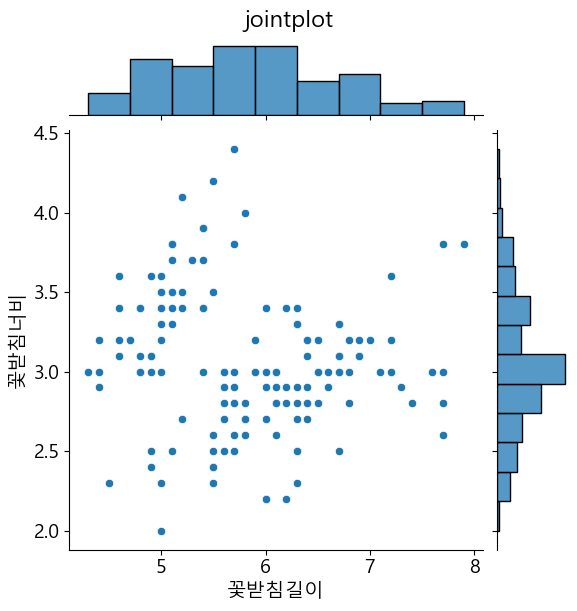

In [8]:
sns.jointplot(data=iris, x='꽃받침길이',y='꽃받침너비')
plt.suptitle('jointplot', y=1.02)
plt.show()

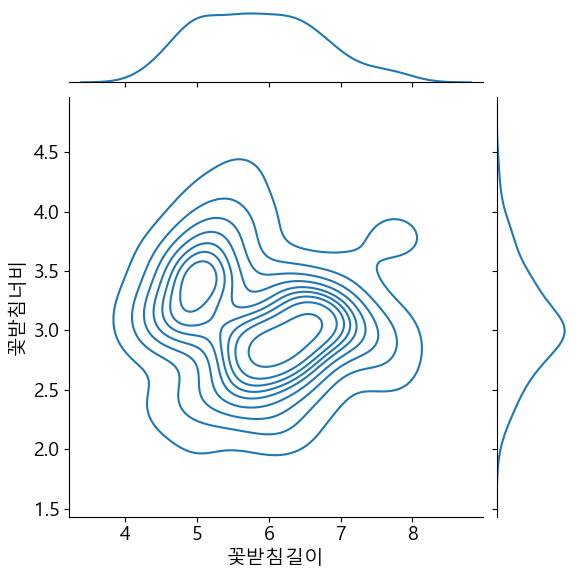

In [11]:
# jointplot을 그릴 때 kind에 kde를 넣어주면 kde 밀도 그래프를 그릴 수 있다.
# 중앙에는 x축과 y축을 이용해 kde를 표현한다.
# 상단에는 x축의 데이터를 이용한 kde를 표현한다.
# 우측에는 y축의 데이터를 이요한 kde를 표현한다.
sns.jointplot(data=iris, x='꽃받침길이',y='꽃받침너비',kind='kde')
plt.show()

### PairPlot
- 산점도의 경우에는 2차원 데이터, 즉 컬럼 두 개를 지정하여 표현한다.
- 만약 데이터 프레임의 컬럼이 다수인 경우 산점도로 그리려면 개발자가 꽤 많은 그래프를 그려야 한다.
- PairPlot은 데이터 프레임의 각 컬럼들을 조합한 산점도를 모두 표현해준다.
- 같은 컬럼의 조합에서는 히스토그램을 그려준다.

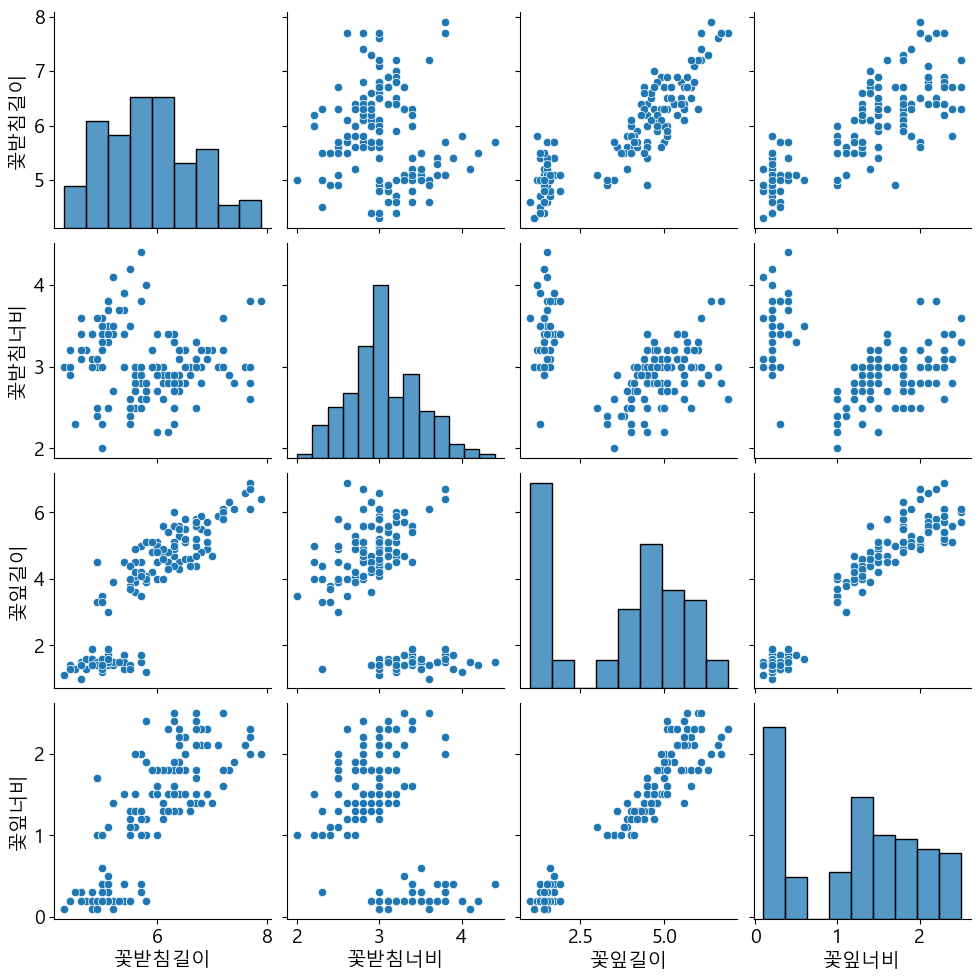

In [12]:
# 수치형 데이터만 모아서 그릴 수 있다.
a1 = iris.drop('품종', axis=1)

sns.pairplot(a1)
plt.show()

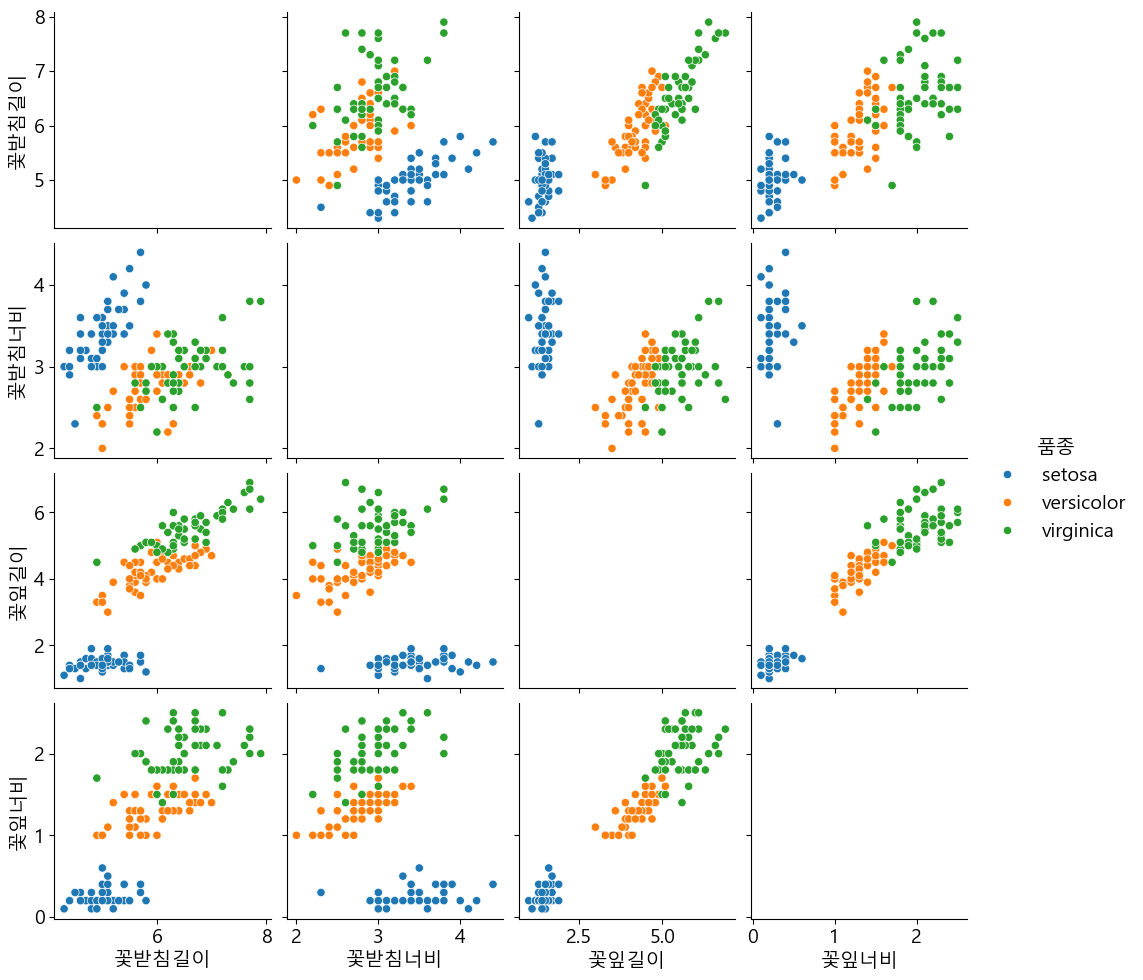

In [13]:
# hue : 각 행들을 구분하기 위한 컬럼을 지정한다.
# 지정한 컬럼의 값에 따라 점의 색상이 달라진다.
# 같은 컬럼의 조합에서는 kde로 표현된다.
sns.pairplot(iris, hue='품종')
plt.show()

### Heatmap
- 컬럼간의 상관관계나 수치의 크고 작음을 색상으로 표현해 확인할 수 있는 그래프
- 그리고자 할 때 사용할 값들을 미리 준비해야 한다.

In [14]:
flights = sns.load_dataset('flights')
flights

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


In [15]:
# pivot 테이블을 구한다.
# 데이터 프레임의 컬럼 하나를 컬럼으로, 컬럼 하나를 행으로 지정하여 3번쨰 지정된 컬럼을 값으로하는 데이터 프레임을 생성한다.
df = flights.pivot_table(index='month', columns='year', values='passengers')
df

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


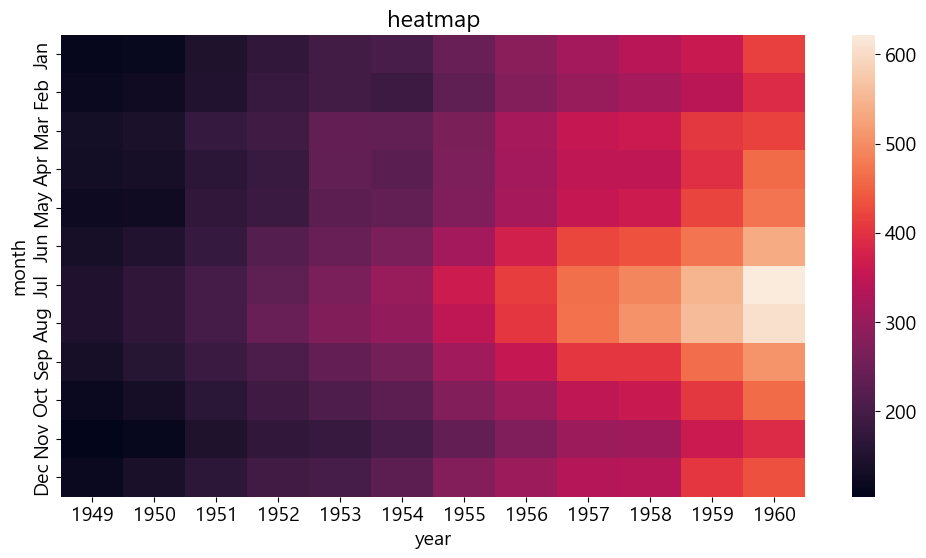

In [16]:
sns.heatmap(df)
plt.title('heatmap')
plt.show()

### 산점도
- x에 지정할 컬럼명과 y에 지정할 컬럼명을 명시해줘야 한다.

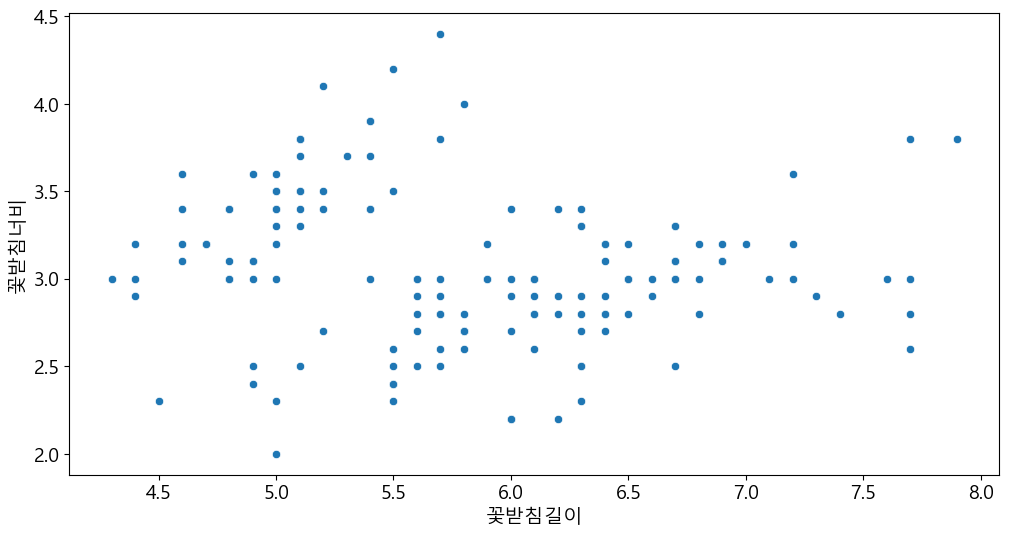

In [17]:
sns.scatterplot(data=iris, x='꽃받침길이', y='꽃받침너비')
plt.show()

### 선 그래프
- 주어진 데이터의 통계량 값을 구해 선 그래프를 그린다.

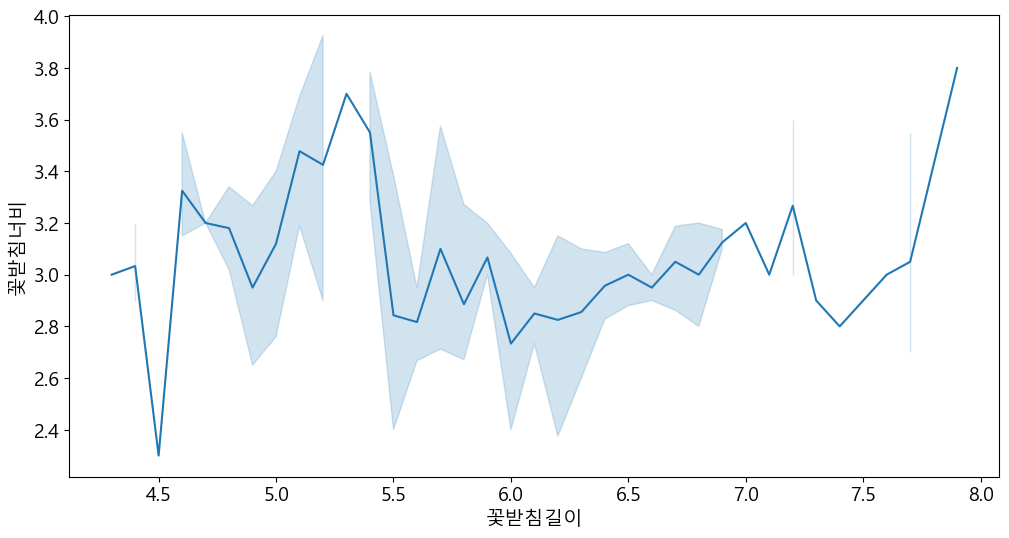

In [20]:
sns.lineplot(data=iris, x='꽃받침길이',y='꽃받침너비')  # errorbar=None 넣으면 면적부분 안 나옴 (신뢰구간)
plt.show()

### 히스토그램과 KDE를 같이 표현할 수 있다.

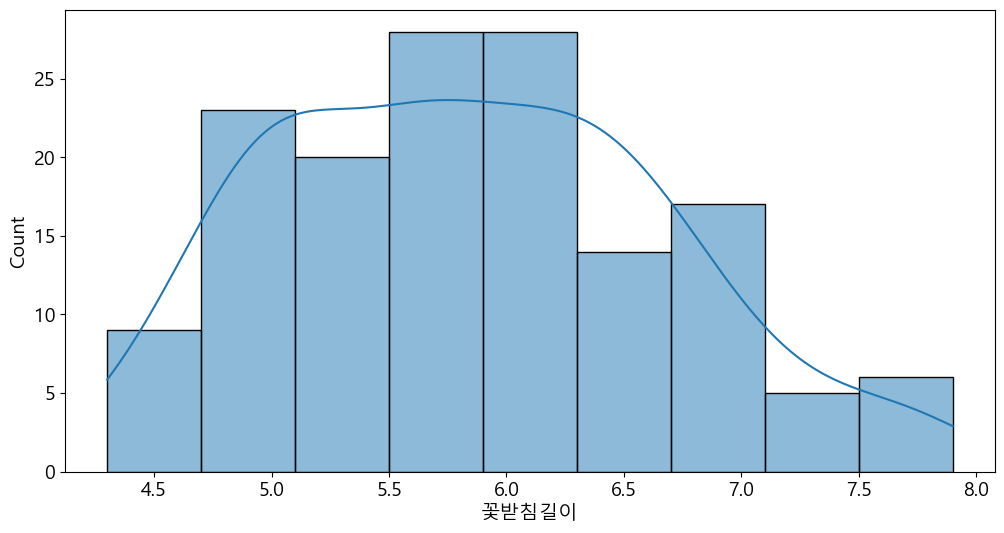

In [21]:
sns.histplot(data=iris, x='꽃받침길이', kde=True)
plt.show()

### 선형회귀 선
- 통계학에 나오는 선형회귀는 주어진 데이터를 일반화한 선을 찾는 예측 통계이다.
- 선형회귀를 통해 예측선을 그려준다.

<Axes: xlabel='꽃받침길이', ylabel='꽃받침너비'>

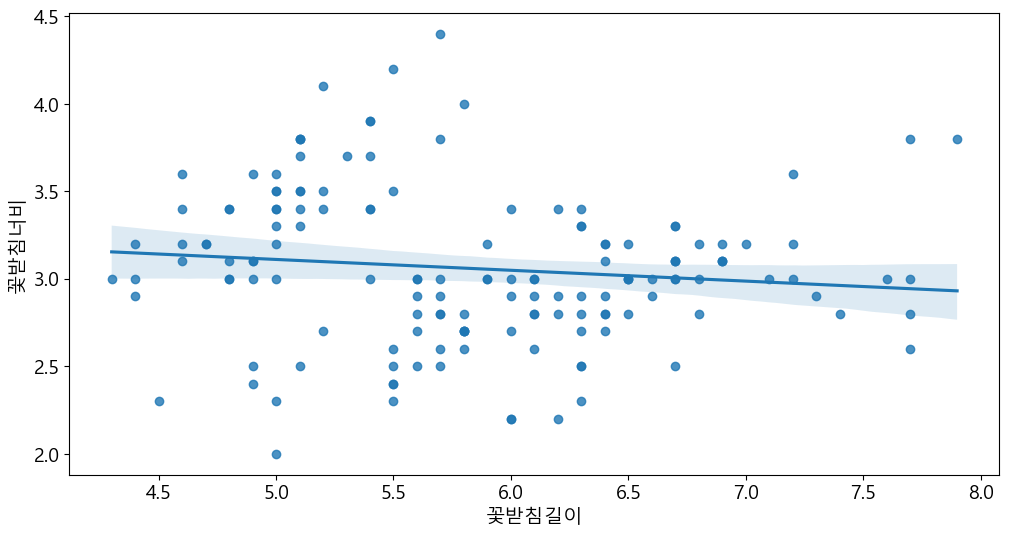

In [27]:
sns.regplot(data=iris, x='꽃받침길이',y='꽃받침너비')